# Property Price Prediction

This notebook walks through data cleaning, EDA, preprocessing, model training, and evaluation for a residential housing price prediction model.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../data/raw/housing_data.csv')
df.head()

,location,area_sqft,bedrooms,bathrooms,stories,age_years,garage,balcony,basement,nearby_school_score,crime_rate,property_type,price
0,Downtown,642,2,3,3,22,2,1,0,6.88,1.28,Villa,723692.22
1,Uptown,1342,2,2,2,26,0,0,1,8.14,0.80,Apartment,745493.40
2,Hillview,1104,1,2,3,26,2,0,1,7.53,0.87,Condo,788793.86
3,Old Town,863,2,2,2,11,0,1,1,9.68,1.29,Villa,697185.47
4,Old Town,1443,3,3,2,25,2,1,1,7.05,1.31,Condo,800754.27


In [3]:
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
df = df.dropna(subset=['price']).copy()
for col in ['area_sqft','bedrooms','bathrooms','stories','age_years','garage','balcony','basement','nearby_school_score','crime_rate','price']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['area_sqft','bedrooms','bathrooms','stories','age_years','garage','balcony','basement','nearby_school_score','crime_rate','price'])
df['location'] = df['location'].astype(str).str.strip().str.title()
df['property_type']= df['property_type'].astype(str).str.strip().str.title()
df.head()

,location,area_sqft,bedrooms,bathrooms,stories,age_years,garage,balcony,basement,nearby_school_score,crime_rate,property_type,price
0,Downtown,642,2,3,3,22,2,1,0,6.88,1.28,Villa,723692.22
1,Uptown,1342,2,2,2,26,0,0,1,8.14,0.80,Apartment,745493.40
2,Hillview,1104,1,2,3,26,2,0,1,7.53,0.87,Condo,788793.86
3,Old Town,863,2,2,2,11,0,1,1,9.68,1.29,Villa,697185.47
4,Old Town,1443,3,3,2,25,2,1,1,7.05,1.31,Condo,800754.27


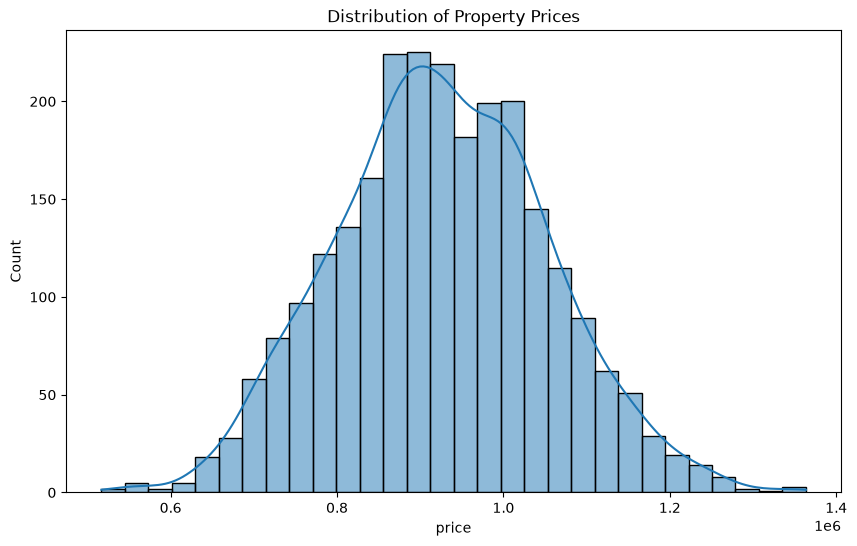

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Property Prices')
plt.show()

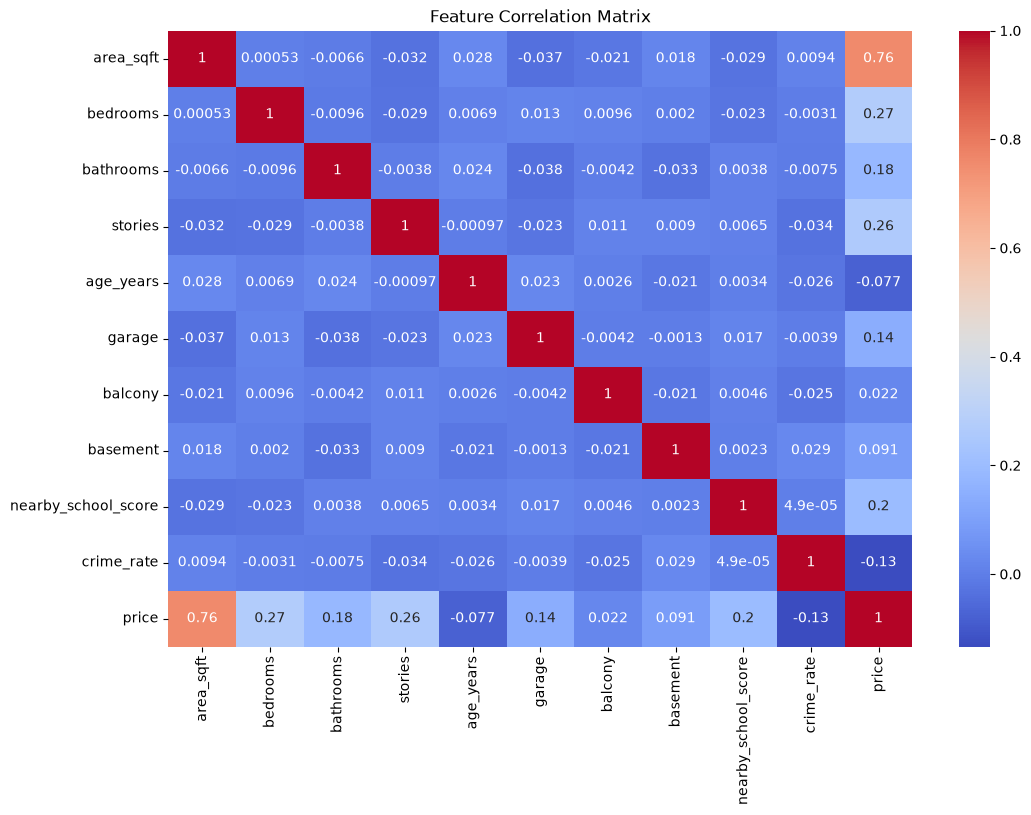

In [5]:
corr = df.select_dtypes(include=['number']).corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [6]:
X = df.drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[('numeric', numeric_transformer, numeric_features), ('categorical', categorical_transformer, categorical_features)])
model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05))])
model.fit(X_train, y_train)
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
import numpy as np
rmse =np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'MAE: {mae:,.2f}')
print(f'MSE: {mse:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R2: {r2:.4f}')

MAE: 25,680.30
MSE: 1,068,583,270.71
RMSE: 32,689.19
R2: 0.9291
